## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
## Model Training
#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.
# !pip install catboost
! pip install pandas


In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('raw.csv')
#help to convert the given data in pandas dataframe called df

#### Show Top 5 Records

In [4]:
df.head()
#return the first 5 rows of dataframe df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [5]:
X = df.drop(columns=['math score'],axis=1)
#create X which is a copy of the original dataframe df,but without the 'math score' column

In [6]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())
#helps to get all unique value out of dataframe df

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [8]:
y = df['math score']
print(y)
#y store all values of math score

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64


In [9]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)#This allows for an efficient and consistent way to preprocess your data before feeding it into a machine learning model.
#preproess a dataset

In [10]:
X = preprocessor.fit_transform(X)

In [11]:
X.shape

(1000, 19)

In [12]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [13]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

##calculating accuracy for traininng set

Optimizing hyperparameters for Random Forest Regressor...
Optimizing hyperparameters for Support Vector Regressor...
Optimizing hyperparameters for XGBoost Regressor...

Individual Model Performance:
                      Model  Train MAE  Train RMSE  Train R2
0   Random Forest Regressor   2.274498    2.761831  0.966166
1  Support Vector Regressor   4.326989    5.494467  0.866092
2         XGBoost Regressor   3.216862    4.034524  0.927800

Stacking Regressor Model performance for Training set
- Mean Absolute Error: 3.5825
- Root Mean Squared Error: 4.4948
- R2 Score: 0.9104

Comparison of actual values, predicted values, and differences:
     Actual  Predicted  Difference
29       62  63.984358   -1.984358
535      66  67.065801   -1.065801
695      79  77.558585    1.441415
557      61  65.177200   -4.177200
836      73  70.504350    2.495650


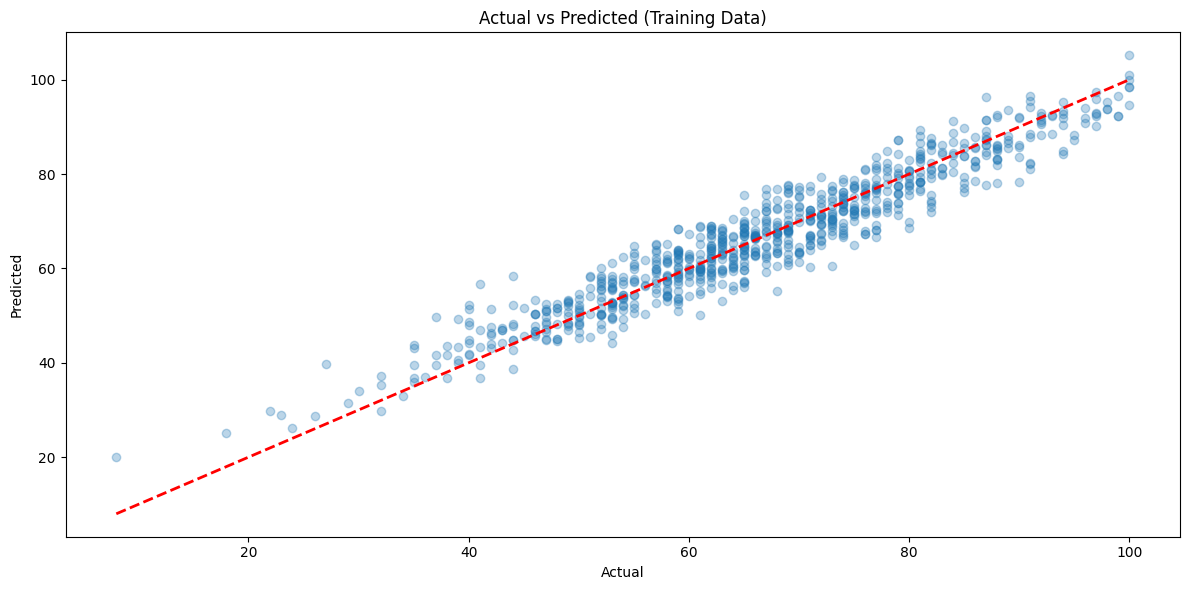

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor, DMatrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor
import sklearn
from packaging import version
import numpy as np

# Use root_mean_squared_error if sklearn version >= 1.4
if version.parse(sklearn.__version__) >= version.parse("1.4"):
    from sklearn.metrics import root_mean_squared_error
    def evaluate_model(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2
else:
    def evaluate_model(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2

# Load and preprocess the data
df = pd.read_csv('raw.csv')

# Create interaction feature
df['Parental_Education_TestPrep'] = df['parental level of education'] + '_' + df['test preparation course']

# Apply Polynomial Features and Binning to Reading and Writing scores
poly = PolynomialFeatures(degree=2, include_bias=False)
binning = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')

df_poly = pd.DataFrame(poly.fit_transform(df[['reading score', 'writing score']]), columns=poly.get_feature_names_out(['reading score', 'writing score']))
df_binned = pd.DataFrame(binning.fit_transform(df[['reading score', 'writing score']]), columns=['reading_score_binned', 'writing_score_binned'])

# Concatenate polynomial features and binned features with the original dataframe
df = pd.concat([df, df_poly, df_binned], axis=1)
df = df.drop(columns=['reading score', 'writing score'])

X = df.drop(columns=['math score'], axis=1)
y = df['math score']

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

X = preprocessor.fit_transform(X)

# Ensure data type compatibility for XGBoost
X = X.astype(np.float32)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the hyperparameter distributions for RandomizedSearchCV
param_distributions = {
    'Random Forest Regressor': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5]
    },
    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'epsilon': [0.1, 0.2],
        'kernel': ['linear', 'rbf']
    },
    'XGBoost Regressor': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
}

# Initialize the models
models = {
    "Random Forest Regressor": RandomForestRegressor(),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor": XGBRegressor(objective='reg:squarederror')
}

# Function for hyperparameter tuning using RandomizedSearchCV
def hyperparameter_tuning(model, param_distribution):
    random_search = RandomizedSearchCV(
        estimator=model, 
        param_distributions=param_distribution, 
        n_iter=min(len(param_distribution), 10),  # Reduce number of iterations
        cv=3,  # Reduce the number of folds
        scoring='r2', 
        n_jobs=-1, 
        random_state=42
    )
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

# Hyperparameter tuning for each model
tuned_models = {}
for model_name, model in models.items():
    print(f"Optimizing hyperparameters for {model_name}...")
    tuned_model = hyperparameter_tuning(model, param_distributions[model_name])
    tuned_models[model_name] = tuned_model

# Define the estimators for stacking
estimators = [(name, tuned_models[name]) for name in tuned_models]

# Define and train the stacking regressor with ElasticNet as meta-model
stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=ElasticNet())
stacking_regressor.fit(X_train, y_train)

# Make predictions with the stacking regressor
y_train_pred_stack = stacking_regressor.predict(X_train)

# Evaluate the stacking model on training data
stack_train_mae, stack_train_rmse, stack_train_r2 = evaluate_model(y_train, y_train_pred_stack)

# Print individual accuracies
results = []
for name, model in tuned_models.items():
    y_train_pred = model.predict(X_train)
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    results.append([name, train_mae, train_rmse, train_r2])

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results, columns=['Model', 'Train MAE', 'Train RMSE', 'Train R2'])

print("\nIndividual Model Performance:")
print(results_df)

print("\nStacking Regressor Model performance for Training set")
print("- Mean Absolute Error: {:.4f}".format(stack_train_mae))
print("- Root Mean Squared Error: {:.4f}".format(stack_train_rmse))
print("- R2 Score: {:.4f}".format(stack_train_r2))

# Create a DataFrame to compare actual vs predicted values
comparison_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred_stack})
comparison_df['Difference'] = comparison_df['Actual'] - comparison_df['Predicted']
print("\nComparison of actual values, predicted values, and differences:")
print(comparison_df.head())

# Plotting the results
plt.figure(figsize=(12, 6))

# Plot actual vs predicted for training data
plt.scatter(y_train, y_train_pred_stack, alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--r', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Training Data)')

plt.tight_layout()
plt.show()




#calculating accuracy for test set

Optimizing hyperparameters for Random Forest Regressor...
Optimizing hyperparameters for Support Vector Regressor...
Optimizing hyperparameters for XGBoost Regressor...

Individual Model Performance:
                      Model  Test MAE  Test RMSE   Test R2
0   Random Forest Regressor  4.601325   5.933601  0.855314
1  Support Vector Regressor  4.245008   5.391829  0.880529
2         XGBoost Regressor  4.297880   5.592418  0.871475

Stacking Regressor Model performance for Test set
- Mean Absolute Error: 4.1771
- Root Mean Squared Error: 5.3471
- R2 Score: 0.8825


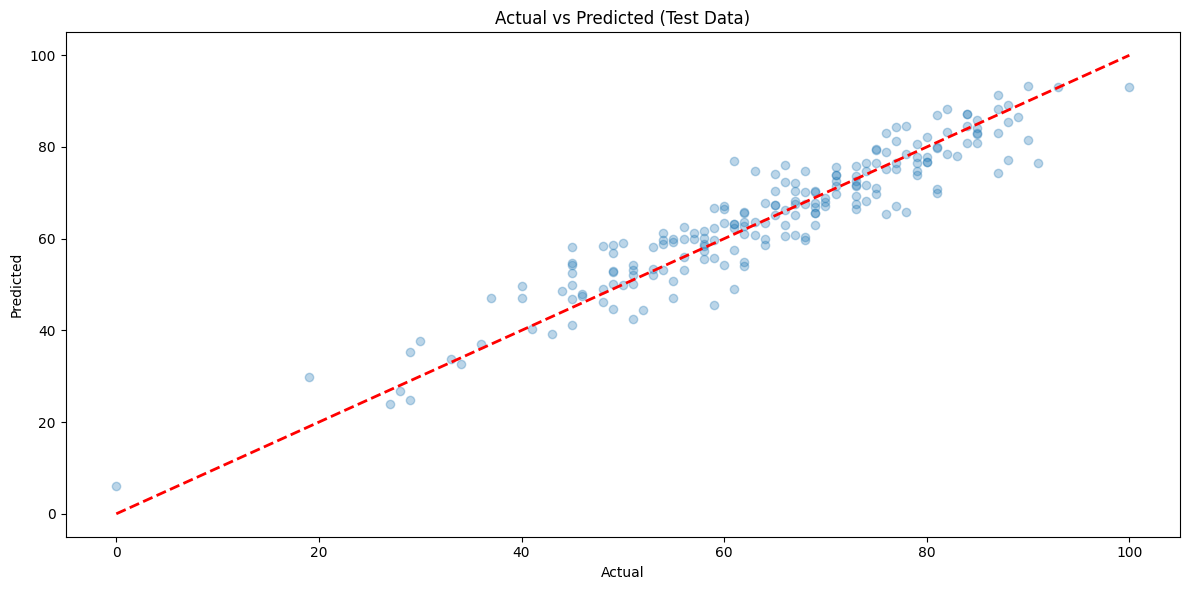

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor
import sklearn
from packaging import version
import numpy as np

# Use root_mean_squared_error if sklearn version >= 1.4
if version.parse(sklearn.__version__) >= version.parse("1.4"):
    from sklearn.metrics import root_mean_squared_error
    def evaluate_model(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2
else:
    def evaluate_model(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2

# Load and preprocess the data
df = pd.read_csv('raw.csv')
X = df.drop(columns=['math score'], axis=1)
y = df['math score']

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

X = preprocessor.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the hyperparameter distributions for RandomizedSearchCV
param_distributions = {
    'Random Forest Regressor': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5]
    },
    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'epsilon': [0.1, 0.2],
        'kernel': ['linear', 'rbf']
    },
    'XGBoost Regressor': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
}

# Initialize the models
models = {
    "Random Forest Regressor": RandomForestRegressor(),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor": XGBRegressor(objective='reg:squarederror')
}

# Function for hyperparameter tuning using RandomizedSearchCV
def hyperparameter_tuning(model, param_distribution):
    random_search = RandomizedSearchCV(
        estimator=model, 
        param_distributions=param_distribution, 
        n_iter=min(len(param_distribution), 10),  # Reduce number of iterations
        cv=3,  # Reduce the number of folds
        scoring='r2', 
        n_jobs=-1, 
        random_state=42
    )
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

# Hyperparameter tuning for each model
tuned_models = {}
for model_name, model in models.items():
    print(f"Optimizing hyperparameters for {model_name}...")
    tuned_model = hyperparameter_tuning(model, param_distributions[model_name])
    tuned_models[model_name] = tuned_model

# Define the estimators for stacking
estimators = [(name, tuned_models[name]) for name in tuned_models]

# Define and train the stacking regressor with ElasticNet as meta-model
stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=ElasticNet())
stacking_regressor.fit(X_train, y_train)

# Make predictions with the stacking regressor
y_test_pred_stack = stacking_regressor.predict(X_test)

# Evaluate the stacking model on test data
stack_test_mae, stack_test_rmse, stack_test_r2 = evaluate_model(y_test, y_test_pred_stack)

# Print individual accuracies
results = []
for name, model in tuned_models.items():
    y_test_pred = model.predict(X_test)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)
    results.append([name, test_mae, test_rmse, test_r2])

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results, columns=['Model', 'Test MAE', 'Test RMSE', 'Test R2'])

print("\nIndividual Model Performance:")
print(results_df)

print("\nStacking Regressor Model performance for Test set")
print("- Mean Absolute Error: {:.4f}".format(stack_test_mae))
print("- Root Mean Squared Error: {:.4f}".format(stack_test_rmse))
print("- R2 Score: {:.4f}".format(stack_test_r2))

# Plotting the results
plt.figure(figsize=(12, 6))

# Plot actual vs predicted for test data
plt.scatter(y_test, y_test_pred_stack, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Test Data)')

plt.tight_layout()
plt.show()




Optimizing hyperparameters for Random Forest Regressor...
Optimizing hyperparameters for Support Vector Regressor...
Optimizing hyperparameters for XGBoost Regressor...


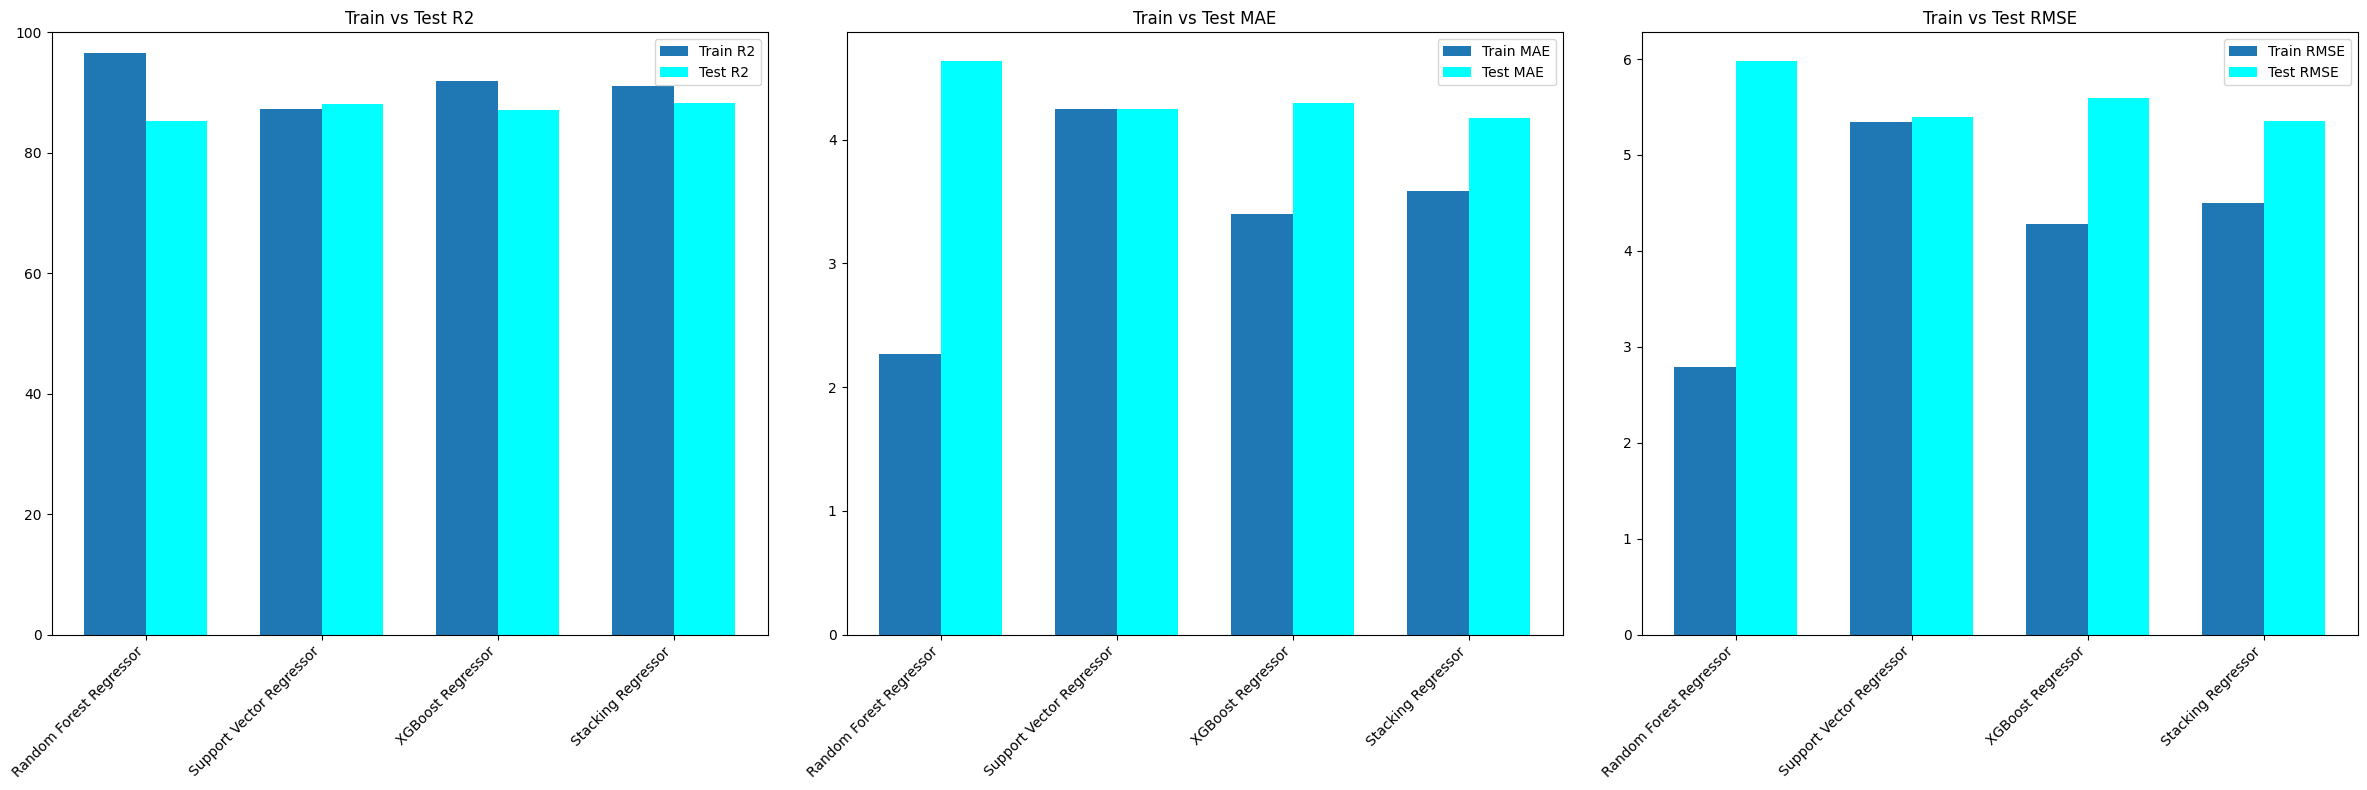

In [16]:


# Use root_mean_squared_error if sklearn version >= 1.4
if version.parse(sklearn.__version__) >= version.parse("1.4"):
    from sklearn.metrics import root_mean_squared_error
    def evaluate_model(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2
else:
    def evaluate_model(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2

# Load and preprocess the data
df = pd.read_csv('raw.csv')
X = df.drop(columns=['math score'], axis=1)
y = df['math score']

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

X = preprocessor.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the hyperparameter distributions for RandomizedSearchCV
param_distributions = {
    'Random Forest Regressor': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5]
    },
    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'epsilon': [0.1, 0.2],
        'kernel': ['linear', 'rbf']
    },
    'XGBoost Regressor': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
}

# Initialize the models
models = {
    "Random Forest Regressor": RandomForestRegressor(),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor": XGBRegressor(objective='reg:squarederror')
}

# Function for hyperparameter tuning using RandomizedSearchCV
def hyperparameter_tuning(model, param_distribution):
    random_search = RandomizedSearchCV(
        estimator=model, 
        param_distributions=param_distribution, 
        n_iter=min(len(param_distribution), 10),  # Reduce number of iterations
        cv=3,  # Reduce the number of folds
        scoring='r2', 
        n_jobs=-1, 
        random_state=42
    )
    random_search.fit(X_train, y_train)
    return random_search.best_estimator_

# Hyperparameter tuning for each model
tuned_models = {}
for model_name, model in models.items():
    print(f"Optimizing hyperparameters for {model_name}...")
    tuned_model = hyperparameter_tuning(model, param_distributions[model_name])
    tuned_models[model_name] = tuned_model

# Define the estimators for stacking
estimators = [(name, tuned_models[name]) for name in tuned_models]

# Define and train the stacking regressor with ElasticNet as meta-model
stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=ElasticNet())
stacking_regressor.fit(X_train, y_train)

# Make predictions with the stacking regressor
y_test_pred_stack = stacking_regressor.predict(X_test)

# Evaluate the stacking model on test data
stack_test_mae, stack_test_rmse, stack_test_r2 = evaluate_model(y_test, y_test_pred_stack)

# Print individual accuracies
results_train = []
results_test = []
for name, model in tuned_models.items():
    y_train_pred = model.predict(X_train)
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    results_train.append([name, train_mae, train_rmse, train_r2])

    y_test_pred = model.predict(X_test)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)
    results_test.append([name, test_mae, test_rmse, test_r2])

# Convert results to DataFrames for better visualization
results_train_df = pd.DataFrame(results_train, columns=['Model', 'Train MAE', 'Train RMSE', 'Train R2'])
results_test_df = pd.DataFrame(results_test, columns=['Model', 'Test MAE', 'Test RMSE', 'Test R2'])

# Adding the stacking regressor results to the dataframes
stack_results_train = ['Stacking Regressor', stack_train_mae, stack_train_rmse, stack_train_r2]
stack_results_test = ['Stacking Regressor', stack_test_mae, stack_test_rmse, stack_test_r2]

# Append stacking results to the original dataframes using concat
results_train_df = pd.concat([results_train_df, pd.DataFrame([stack_results_train], columns=results_train_df.columns)], ignore_index=True)
results_test_df = pd.concat([results_test_df, pd.DataFrame([stack_results_test], columns=results_test_df.columns)], ignore_index=True)

# Ensure no duplicate entries in the dataframes
results_train_df = results_train_df.drop_duplicates(subset=['Model'], keep='last')
results_test_df = results_test_df.drop_duplicates(subset=['Model'], keep='last')

# Multiply R2 scores by 100 to convert to percentage
results_train_df['Train R2'] = results_train_df['Train R2'].astype(float) * 100
results_test_df['Test R2'] = results_test_df['Test R2'].astype(float) * 100

# Plotting the results with clearly visible colors
fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# Define the colors for the train and test sets
color_train = '#1f77b4'  # Dark blue
color_test = '#00FFFF'   # Cyan

# Define bar width
bar_width = 0.35
x = np.arange(len(results_train_df['Model']))

# Plot Train vs Test R2
axs[0].bar(x - bar_width/2, results_train_df['Train R2'], width=bar_width, label='Train R2', color=color_train)
axs[0].bar(x + bar_width/2, results_test_df['Test R2'], width=bar_width, label='Test R2', color=color_test)
axs[0].set_xticks(x)
axs[0].set_xticklabels(results_train_df['Model'], rotation=45, ha='right')
axs[0].set_ylim(0, 100)  # Set y-axis range from 0 to 100
axs[0].set_title('Train vs Test R2')
axs[0].legend()

# Plot Train vs Test MAE
axs[1].bar(x - bar_width/2, results_train_df['Train MAE'], width=bar_width, label='Train MAE', color=color_train)
axs[1].bar(x + bar_width/2, results_test_df['Test MAE'], width=bar_width, label='Test MAE', color=color_test)
axs[1].set_xticks(x)
axs[1].set_xticklabels(results_train_df['Model'], rotation=45, ha='right')
axs[1].set_title('Train vs Test MAE')
axs[1].legend()

# Plot Train vs Test RMSE
axs[2].bar(x - bar_width/2, results_train_df['Train RMSE'], width=bar_width, label='Train RMSE', color=color_train)
axs[2].bar(x + bar_width/2, results_test_df['Test RMSE'], width=bar_width, label='Test RMSE', color=color_test)
axs[2].set_xticks(x)
axs[2].set_xticklabels(results_train_df['Model'], rotation=45, ha='right')
axs[2].set_title('Train vs Test RMSE')
axs[2].legend()

plt.tight_layout()
plt.show()
